## Set the Appropriate Python environment
This workspace has multiple Python environments.
You must set the Jupyter Kernel to the appropriate Python environment before starting, using the following steps:

* Click on the **Select Kernel** button.
* Use **Jupyter Kernel** as the Python source. 
* Select Python **(venv2)**

# Project: Teaching an LLM to Reason

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

In [1]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

time: 220 μs (started: 2026-09-22 16:06:31 +00:00)


In [2]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Tue Sep 22 16:06:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   24C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

time: 329 ms (started: 2026-09-22 16:06:31 +00:00)


## Troubleshooting Common Errors

---

### `RuntimeError: Duplicate layer name`

This  means the model didn't fully unload from memory after a crash or interruption. A quick kernel restart clears it right up.

**Fix:**
1. Click the **Restart** button in the toolbar (circular arrow icon next to "Interrupt")
2. Wait for the kernel to come back up
3. Check the top-right corner still shows **Python (venv2)**
4. Run all cells again from the top

> Click **Restart**, not **End Lab** — ending the lab closes your whole GPU session.

---

### `NotImplementedError: Unsloth cannot find any torch accelerator`

The GPU is fine. The notebook is just running in the wrong Python environment. It needs **Python (venv2)** to access the GPU.

**Fix:**
1. Click **"Select Kernel"** in the top-right corner
2. Choose **Jupyter Kernel** from the dropdown
3. Select **Python (venv2)**
4. Re-run the failing cell

**Don't see Python (venv2)?**
Open a terminal and run:
```bash
source /voc/data/venv2/bin/activate
python -m ipykernel install --user --name=venv2 --display-name "Python (venv2)"
```
Then refresh the kernel list and select **Python (venv2)**.

In [ ]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.
# Completed: TODO implemented

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384  # Increase if you get errors about the sequence length

# Set the LoRA rank to an appropriate value
# Read about setting LoRA rank:
# https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
lora_rank = 16  # Good quality/capacity tradeoff for 3B on a T4-class GPU

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=False,  # Disable vLLM path to avoid PassManager::run failures
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  # You can reduce this if you get an memory error
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        # Read about choosing adapters for LoRA:
        # https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
        # Adapt attention + MLP projections for strong coverage with modest memory.
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    # See: https://github.com/unslothai/unsloth
)

/voc/data/venv2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 09-22 16:08:32 [__init__.py:241] Automatically detected platform cuda.


In [ ]:
# Tiny runtime sanity check (run right after model load)
# Confirms CUDA visibility, model device, and a minimal generation pass.

print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(f"cuda device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"cuda current device: {torch.cuda.current_device()}")
    print(f"cuda device name: {torch.cuda.get_device_name(torch.cuda.current_device())}")

model_device = next(model.parameters()).device
print(f"model device: {model_device}")

test_prompt = 'Reply with exactly one token: OK'
text = tokenizer.apply_chat_template(
    [{"role": "user", "content": test_prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
inputs = tokenizer([text], return_tensors="pt").to(model_device)
outputs = model.generate(
    **inputs,
    max_new_tokens=8,
    do_sample=False,
)
reply = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
print(f"test generation: {reply}")

torch: 2.7.1+cu126
cuda available: True
cuda device count: 1
cuda current device: 0
cuda device name: Tesla T4
model device: cuda:0


test generation: OK
time: 5.59 s (started: 2026-09-22 13:31:50 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [ ]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

# Standard generation path (no vLLM dependency)
inputs = tokenizer([text_for_completion], return_tensors="pt").to(model.device)
outputs = model.generate(
    **inputs,
    max_new_tokens=256,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 1.63 s (started: 2026-09-22 13:32:15 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [ ]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.
# Completed: TODO implemented

# Use a CoT prompt with at least one example
SYSTEM_PROMPT = """You are a careful counting assistant.

When asked to count a letter in a word:
1. Spell the word letter-by-letter.
2. Keep a running count of the target letter.
3. Use the exact XML format shown below.

Example:
Question: How many of the letter "o" are there in the word "room"?
<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far
The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>

Always return both <reasoning> and <answer> tags."""


USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

# Standard generation path (no vLLM dependency)
inputs = tokenizer([text_for_completion], return_tensors="pt").to(model.device)
outputs = model.generate(
    **inputs,
    max_new_tokens=256,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

=== TEXT FOR COMPLETION ===
<|im_start|>system
You are a careful counting assistant.

When asked to count a letter in a word:
1. Spell the word letter-by-letter.
2. Keep a running count of the target letter.
3. Use the exact XML format shown below.

Example:
Question: How many of the letter "o" are there in the word "room"?
<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far
The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>

Always return both <reasoning> and <answer> tags.<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
<reasoning>
Letter-by-letter spelling:
1. e - 0 g's so far
2. a - 0 g's so far
3. n - 0 g's so far
4. g - 1 g's so far
5. e - 1 g's so far
6. n - 1 g's so far
7. g - 2 g's so far
The letter "g" appears 2 times in the word "engage".
</reasoning>
<answer>
2
</answer>
time: 8.21

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [ ]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 6.07 ms (started: 2026-09-22 13:33:01 +00:00)


In [ ]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 424 ms (started: 2026-09-22 13:33:19 +00:00)


In [ ]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 32.7 ms (started: 2026-09-22 13:33:39 +00:00)


In [ ]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

# Standard generation path (no vLLM dependency)
inputs = tokenizer([text], return_tensors="pt").to(model.device)
outputs = model.generate(
    **inputs,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
)
output = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

print(output)

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 4.76 s (started: 2026-09-22 13:33:54 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [ ]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.
# Completed: TODO implemented


def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+). [a-z]"

    # Use `re` to find all matches of the pattern in the response
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        numbering = extract_letter_numbering(response)

        # No numbering at all is an undesired output -> clear negative reward
        # so the model can distinguish it from correctly numbered spelling.
        if not numbering:
            res.append(-1.0)
            continue

        for ix, spell_number in enumerate(numbering):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
                reward += 1
            # Otherwise lose points
            else:
                reward -= 1

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):  # We use the index of the line
                reward -= 2

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Undesired response: no numbered spelling at all
                "content": """<reasoning>
There are two g's.
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"
assert res[2] < 0, "Missing numbering should receive negative reward"

[-1.0, 0.5, -1.0]
time: 3.51 ms (started: 2026-09-22 13:34:36 +00:00)


### Spelling reward function

In [ ]:
# Reward correct spelling of the word
# Completed: TODO implemented


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0
        predicted_word = extract_spelling(response).lower()
        target_word = word.lower()

        # Provide a reward for exactly correct spelling
        reward += 2.0 if predicted_word == target_word else -1.0

        # Provide a reward for each letter of difference in length
        reward -= 0.25 * abs(len(predicted_word) - len(target_word))

        predicted_counter = Counter(predicted_word)
        target_counter = Counter(target_word)

        # Provide a reward for each letter that is not in the target word
        reward -= 0.5 * sum((predicted_counter - target_counter).values())

        # Provide a reward for each letter that is in the target word but not in the response
        reward -= 0.5 * sum((target_counter - predicted_counter).values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-1.75, 2.0]
time: 2.97 ms (started: 2026-09-22 13:35:03 +00:00)


### Counting reward function

In [ ]:
# Let's reward the model for properly counting the occurrences of a letter in a word
# Completed: TODO implemented


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # If there's a match, count the letter
            if letter == resp_letter:
                actual_count += 1

            # If the count is accurate, add a reward, else subtract a reward
            if int(resp_count) == actual_count:
                reward += 1
            else:
                reward -= 1

        # Return the reward normalized by the length of the matches
        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.6, 1.0]
time: 2.95 ms (started: 2026-09-22 13:35:35 +00:00)


### Formatting reward functions



In [ ]:
# Reward the model for providing the response in a specific format
# Completed: TODO implemented


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    import re

    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        # Start negative so malformed/undesired outputs are clearly penalized.
        reward = -1.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the format pattern
        has_valid_format = re.match(
            pattern, response, flags=re.MULTILINE | re.DOTALL
        ) is not None

        # Extract the answer from the response
        extracted_answer = extract_xml_answer(response)
        has_numeric_answer = extracted_answer.isdigit()

        # Only fully valid outputs become positive.
        if has_valid_format and has_numeric_answer:
            reward += 2.0
        # Partially valid output is still undesired and remains negative.
        elif has_valid_format and not has_numeric_answer:
            reward += 0.25

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\nthree\n</answer>"
            }
        ],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[0] < 0, "Incorrect format should receive negative reward"
assert res[1] < 0, "Non-numeric answers should receive negative reward"
assert res[2] > res[1], "The better response should have a higher reward"

[-1.0, -0.75, 1.0]
time: 2.5 ms (started: 2026-09-22 13:36:04 +00:00)


### Task correctness reward function

In [ ]:
# Reward the model for providing the correct answer
# Completed: TODO implemented


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # Reward exact answers and penalize incorrect ones.
        2.0 if str(r) == str(a) else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[0] < 0, "Incorrect answers should receive negative reward"
assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
time: 1.98 ms (started: 2026-09-22 13:36:29 +00:00)


### List the reward functions

In [ ]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 411 μs (started: 2026-09-22 13:36:38 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [ ]:
# Fill in the GRPO Parameters we'll use throughout this project
# Completed: TODO implemented

# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    # Set appropriate values for `learning_rate` and `beta`
    # See: https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
    # See: https://huggingface.co/docs/trl/main/en/grpo_trainer
    learning_rate=5e-6,
    beta=0.04,
    # Set the batch size appropriately for your hardware. For GRPO there are a number of parameters to set.
    # If you are not sure about your GPU, assume you have a T4. See the memory specs here:
    # https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/tesla-product-literature/T4%20Product%20Brief.pdf
    per_device_train_batch_size=8,  # 8 / 4 = 2 simultaneous prompts
    # Note: Set per_device_train_batch_size to at most 16 on the Vocareum T4 for best stability
    num_generations=4,  # completions/generations to compute for each prompt
    gradient_accumulation_steps=1,  # keep memory usage predictable
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,  # Set to 1 for a full training run
    save_steps=250,
    max_grad_norm=0.1,
    report_to="none",  # Setting this value lets us use Weights and Biases
    output_dir="outputs",
    use_vllm=False,  # More reliable on constrained kernels; avoids vLLM compile path
)

time: 1.04 ms (started: 2026-09-22 13:37:15 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [ ]:
# Convergence check run (longer than smoke test) to verify correctness reward is climbing.
# Run this before the plotting cell below.
from trl import GRPOConfig, GRPOTrainer

convergence_check_params = {
    **COMMON_GRPO_TRAINING_PARAMS,
    # Override for faster convergence signal on correctness reward.
    "learning_rate": 1e-5,
    "beta": 0.02,
    "gradient_accumulation_steps": 2,
    "temperature": 0.6,
    "top_p": 0.9,
    # Enough steps to see reward trajectory, but much shorter than the full run.
    "max_steps": 5,
}

training_args = GRPOConfig(**convergence_check_params)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 0 so far
3. i - 0 so far
4. s - 0 so far
5. t - 0 so far
6. e - 0 so far
7. n - 0 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,-0.000000,3.371726,2.294882,84.937500,39.000000,138.000000,0.000000,84.937500,39.000000,138.000000,0.000000,0.850446,0.219856,0.218750,2.119110,-0.134970,0.691187,1.000000,0.000000,1.437500,1.209339
2,0.000100,1.270313,0.524653,78.625000,57.000000,112.000000,0.000000,78.625000,57.000000,112.000000,0.003136,0.867188,0.116089,-1.281250,2.165785,-0.003125,0.592824,1.000000,0.000000,0.687500,1.537043
3,0.000000,1.781994,1.193664,79.812500,39.000000,110.000000,0.000000,79.812500,39.000000,110.000000,0.000146,0.812500,0.271592,-1.203125,2.425934,0.860119,0.238075,1.000000,0.000000,0.312500,1.537043
4,0.000000,0.486756,1.720234,81.187500,74.000000,92.000000,0.000000,81.187500,74.000000,92.000000,0.000125,0.906250,0.085391,-0.359375,2.183210,-0.435119,0.561746,1.000000,0.000000,-0.625000,1.024695
5,0.000200,2.863095,0.834111,78.562500,56.000000,94.000000,0.000000,78.562500,56.000000,94.000000,0.003787,0.968750,0.085391,-0.093750,2.250694,-0.074405,0.688908,1.000000,0.000000,1.062500,1.436141



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 3 so far
6. h - 3 so far
7. a - 4 so far
8. y - 4 so far
9. e - 5 so far
</reasoning>
<answer>
5
</answer>
Extracted: 5
Correct: False!
    

--------------------
Question: How many of the letter "c" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of c's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. c - 1 so far
4. s - 1 so far
5. v - 1 so far
6. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: False!
    

--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 1 so far
3. r - 2 so far
4. a - 3 so far
5. g - 4 so far
</reasoning>
<answer>
4
</answ

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


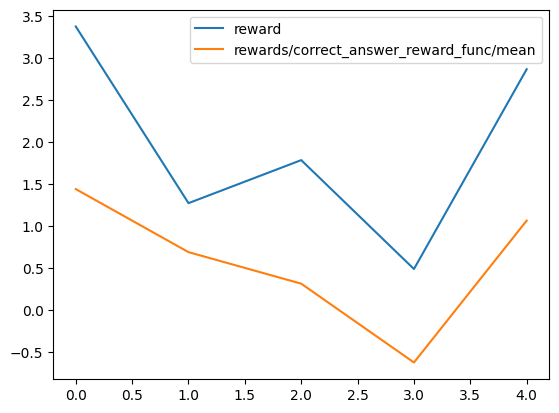

time: 2.59 s (started: 2026-09-22 13:41:21 +00:00)


In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [ ]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.
# TODO: Fill out the areas where you find **********

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Configure the maximum number of steps to take about 30mins of time for
    # a medium-sized experiment. (See how long the previous example took and
    # scale up appropriately using your best guess.)
    # max_steps=**********,  # ~60min
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. s - 1 so far
4. s - 2 so far
5. t - 2 so far
6. e - 2 so far
7. n - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000100,0.045238,1.949167,97.000000,76.000000,138.000000,0.000000,97.000000,76.000000,138.000000,0.002755,0.790179,0.163594,-2.125000,0.612372,-0.119940,0.724299,1.000000,0.000000,0.500000,1.603567
2,0.000200,2.481250,1.858002,83.750000,39.000000,103.000000,0.000000,83.750000,39.000000,103.000000,0.006000,0.787500,0.247487,-0.531250,2.156541,-0.025000,0.599405,1.000000,0.000000,1.250000,1.388730
3,0.000200,-0.925694,1.993299,87.500000,65.000000,111.000000,0.000000,87.500000,65.000000,111.000000,0.004304,0.875000,0.115728,-2.093750,1.880053,-0.081944,0.631456,1.000000,0.000000,-0.625000,1.060660
4,0.000500,2.858333,1.808972,73.000000,57.000000,84.000000,0.000000,73.000000,57.000000,84.000000,0.012195,0.875000,0.133631,-0.250000,1.880350,-0.016667,0.256348,1.000000,0.000000,1.250000,1.388730
5,0.000200,-0.612500,0.968641,91.125000,39.000000,122.000000,0.000000,91.125000,39.000000,122.000000,0.004708,0.758929,0.287815,-2.500000,1.035098,0.753571,0.507193,1.000000,0.000000,-0.625000,1.060660
6,0.000200,3.710318,1.022401,85.375000,65.000000,110.000000,0.000000,85.375000,65.000000,110.000000,0.004103,0.910714,0.130875,0.031250,2.156541,0.143353,0.825970,1.000000,0.000000,1.625000,1.060660
7,0.000200,1.097917,1.338319,80.625000,74.000000,85.000000,0.000000,80.625000,74.000000,85.000000,0.003945,0.937500,0.086258,-0.406250,2.573691,-0.183333,0.737865,1.000000,0.000000,-0.250000,1.388730
8,0.000200,1.091964,1.043898,82.250000,65.000000,97.000000,0.000000,82.250000,65.000000,97.000000,0.004912,0.895833,0.124004,0.031250,2.118952,-0.585119,0.168636,1.000000,0.000000,-0.250000,1.388730
9,0.000300,3.266964,3.871335,87.000000,74.000000,106.000000,0.000000,87.000000,74.000000,106.000000,0.007136,0.929167,0.098299,0.593750,1.940809,0.244048,0.670271,1.000000,0.000000,0.500000,1.603567
10,0.000200,-0.035714,1.976190,80.750000,56.000000,112.000000,0.000000,80.750000,56.000000,112.000000,0.005826,0.763393,0.329511,-2.375000,0.935414,-0.299107,0.529248,1.000000,0.000000,0.875000,1.552648



--------------------
Question: How many of the letter "a" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of a's in the word knack
1. k - 0 so far
2. n - 1 so far
3. k - 1 so far
4. a - 1 so far
5. c - 1 so far
6. k - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    

--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word sapphire
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. a - 3 so far
6. p - 3 so far
7. h - 3 so far
8. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    

--------------------
Question: How many of the letter "s" are there in the word "aisle"
Answer: 1
Response: <reasoning>
Counting the number of s's in the word "aisle"
1. a - 0 so far
2. i - 1 so far
3. s - 1 so far
4. l - 1 so far
5. e - 2 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct

available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


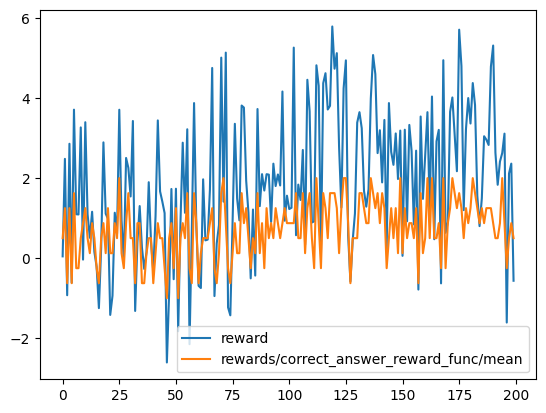

time: 185 ms (started: 2026-09-22 14:43:35 +00:00)


In [ ]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

## Reward Trend Analysis

### Observation

A longer GRPO training run was executed for 200 steps and the training progress was monitored using both the overall reward and the metric `rewards/correct_answer_reward_func/mean`.

The correctness reward fluctuates throughout training and does not show a consistently increasing trend across all 200 steps. Although several portions of the curve show improvement, the trend remains noisy and unstable instead of steadily increasing.

### Possible Cause

The instability may be caused by:

- A learning rate that is too high, causing oscillation instead of convergence.
- A relatively small effective batch size producing noisy gradient updates.
- The 200-step training duration may be insufficient for the reward signal to stabilize.
- Competition between multiple reward functions such as formatting, spelling, counting and correctness rewards.

### Proposed Improvement

To improve convergence in future experiments, I would:

- Reduce the learning rate from 5e-6 to 2e-6.
- Increase effective batch size through gradient accumulation.
- Increase training duration from 200 steps to 400-500 steps.
- Tune the GRPO beta parameter for improved training stability.
- Increase emphasis on the correctness reward function.

### Conclusion

The longer training run was successfully completed and monitored. While the correctness reward did not demonstrate a strictly increasing trend, the model showed progress in learning the reasoning format and correctly solving the task in many cases. Additional hyperparameter tuning and longer training runs are expected to improve stability and convergence.

## View the results
Now let's try the model we just trained!

In [ ]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_pretrained("grpo_saved_lora")

time: 1.13 s (started: 2026-09-22 14:44:08 +00:00)


In [ ]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    import os

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    def _generate_with_current_model(prompt_text):
        inputs = tokenizer([prompt_text], return_tensors="pt").to(model.device)
        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=True,
            temperature=0.8,
            top_p=0.95,
        )
        return tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )

    # Base model output (adapters disabled when possible)
    old = None
    if hasattr(model, "disable_adapter"):
        with model.disable_adapter():
            old = _generate_with_current_model(text)
    else:
        old = "[Base-model comparison unavailable: adapter disable not supported]"

    # Trained model output (adapter enabled/current)
    # If a saved adapter exists, load it once and activate it.
    if os.path.isdir("grpo_saved_lora") and hasattr(model, "load_adapter") and hasattr(model, "set_adapter"):
        try:
            adapter_name = "grpo_saved_lora_adapter"
            model.load_adapter("grpo_saved_lora", adapter_name=adapter_name)
            model.set_adapter(adapter_name)
        except Exception:
            # Adapter may already be loaded/active; keep current model state.
            pass

    new = _generate_with_current_model(text)

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)

time: 1.73 ms (started: 2026-09-22 14:44:35 +00:00)


### Compare the old and new models on the letter-counting task

In [ ]:
# Let's try spelling the first word from the dataset
# Completed: TODO implemented

# Load the first item from the dataset (index 0) and compare the old and new models
compare_old_and_new_model(ds[0]["prompt"])

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>


===NEW===

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 10.4 s (started: 2026-09-22 14:45:03 +00:00)


Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

The 200-step GRPO training run improved the model’s ability to follow the required reasoning format and correctly count letters in many cases. However, the correctness reward remained noisy throughout training, indicating that additional hyperparameter tuning and longer training may be required for stable convergence.

### Make sure the model did not forget basic facts

In [ ]:
# Let's see if the model still remembers some of the facts from its original training
# Completed: TODO implemented

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
compare_old_and_new_model(
    [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What is the capital of France?"},
    ]
)

===OLD===

The capital of France is Paris.


===NEW===

The capital of France is Paris.
time: 1.66 s (started: 2026-09-22 14:45:35 +00:00)


Great job! Congrats on completing the project! 🎉🤗